# 02 - Heat Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t = \alpha u_{xx}$, $\alpha = 0.01$

**IC:** $u(x,0) = \sin(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 32, 32, 32, 1]` | **Epochs:** 10000

**Note:** Heat equation is smooth - used as baseline to confirm AC-PINN
does not hurt performance on easy problems.

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    HeatFDM, Benchmark, save_metrics, save_history
)

PDE        = 'heat'
LAYERS     = [2, 32, 32, 32, 1]
EPOCHS     = 10000
PDE_PARAMS = {'alpha': 0.01}
RESULTS    = '../results/heat/'
FIGURES    = '../figures/heat/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE, alpha=0.01)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

HeatFDM solved in 0.6913s


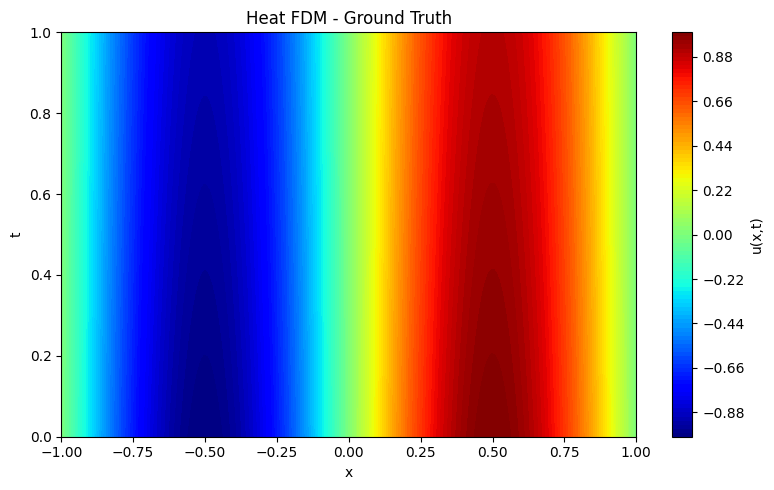

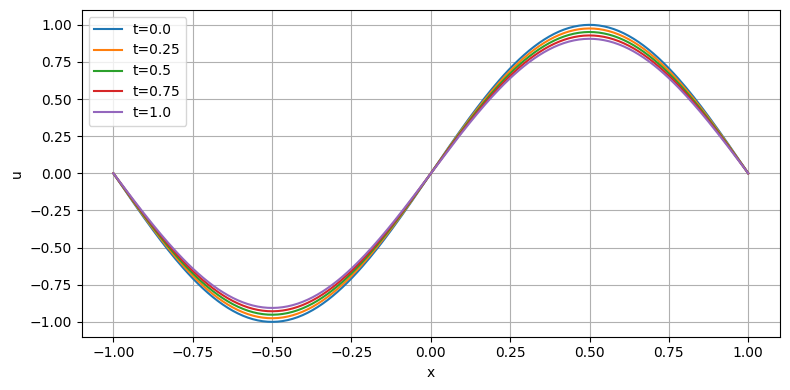

In [2]:
fdm = HeatFDM(nx=256, nt=1000, alpha=0.01)
fdm.solve()
fdm.plot_solution(title='Heat FDM - Ground Truth')
fdm.plot_time_slices()

## Section 2 - Data Conditions

In [3]:
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=8000, noise_eps=0.0)
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=2000, noise_eps=0.1)
print('Data ready')

Data ready


## Section 3 - Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     0 | Total: 1.307864 | IC: 0.209568 | BC: 0.654181 | PDE: 0.088823


Epoch  1000 | Total: 0.001321 | IC: 0.000542 | BC: 0.000065 | PDE: 0.000143


Epoch  2000 | Total: 0.000106 | IC: 0.000044 | BC: 0.000009 | PDE: 0.000011


Epoch  3000 | Total: 0.000079 | IC: 0.000023 | BC: 0.000024 | PDE: 0.000006


...

Epoch  6000 | Total: 0.000039 | IC: 0.000008 | BC: 0.000014 | PDE: 0.000003


Epoch  7000 | Total: 0.000037 | IC: 0.000008 | BC: 0.000014 | PDE: 0.000003


Epoch  8000 | Total: 0.000089 | IC: 0.000017 | BC: 0.000058 | PDE: 0.000003


Epoch  9000 | Total: 0.000032 | IC: 0.000006 | BC: 0.000012 | PDE: 0.000003



Training complete in 234.81s


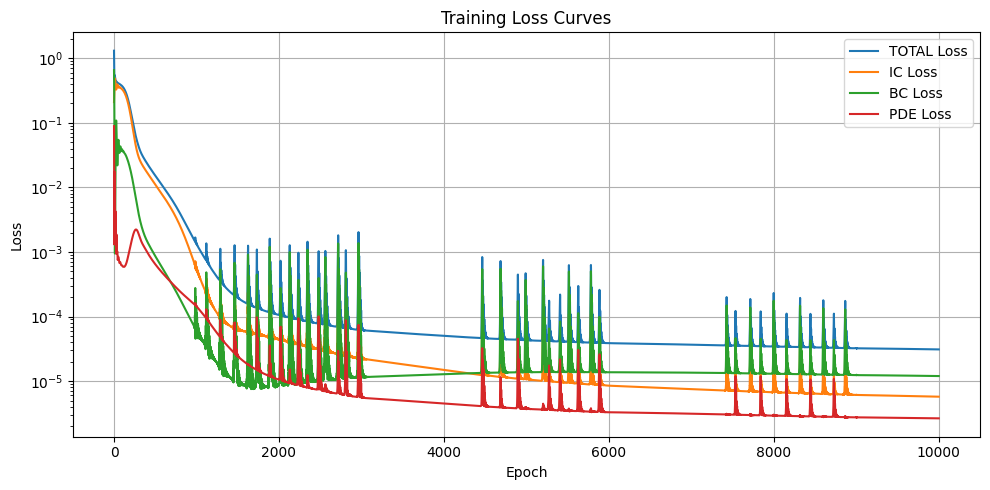

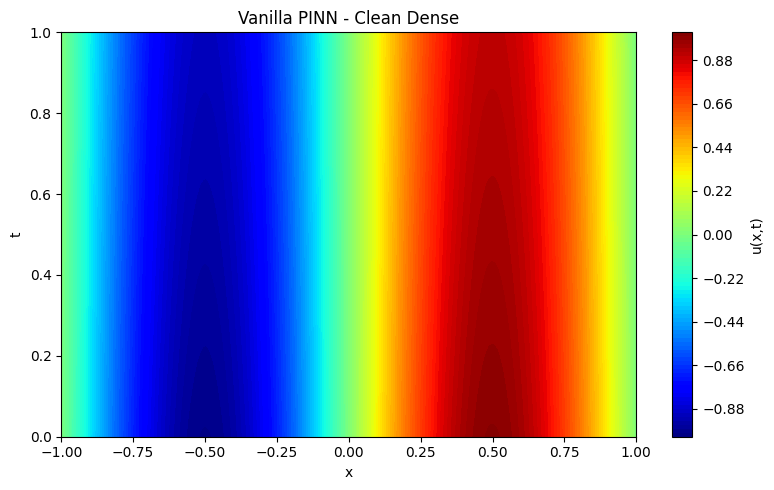

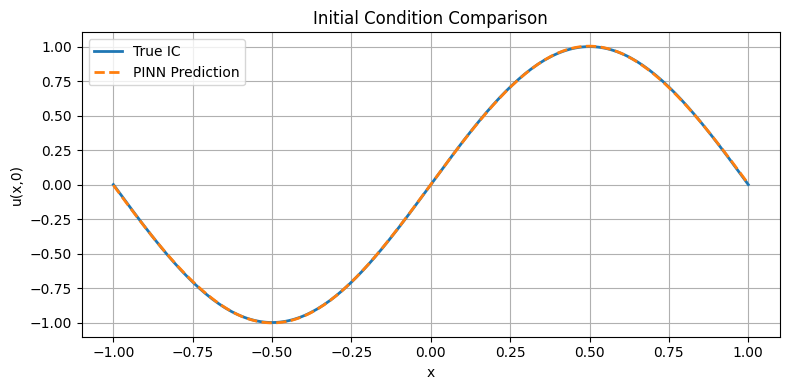

Saved: ../results/heat/vanilla_clean_history.npy


In [4]:
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Heat | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS+'vanilla_clean_history.npy')

## Section 4 - Vanilla PINN, Noisy Sparse

Epoch     0 | Total: 1.242760 | IC: 0.796791 | BC: 0.110370 | PDE: 0.067120


Epoch  1000 | Total: 0.027351 | IC: 0.011443 | BC: 0.015612 | PDE: 0.000059


Epoch  2000 | Total: 0.026694 | IC: 0.010893 | BC: 0.015511 | PDE: 0.000058


Epoch  3000 | Total: 0.026465 | IC: 0.010749 | BC: 0.015374 | PDE: 0.000068


Epoch  4000 | Total: 0.026290 | IC: 0.010686 | BC: 0.015264 | PDE: 0.000068


...

Epoch  6000 | Total: 0.025418 | IC: 0.010314 | BC: 0.014692 | PDE: 0.000083


Epoch  7000 | Total: 0.025219 | IC: 0.010199 | BC: 0.014560 | PDE: 0.000092


Epoch  8000 | Total: 0.025012 | IC: 0.010103 | BC: 0.014423 | PDE: 0.000097


Epoch  9000 | Total: 0.024800 | IC: 0.010030 | BC: 0.014272 | PDE: 0.000100



Training complete in 231.31s


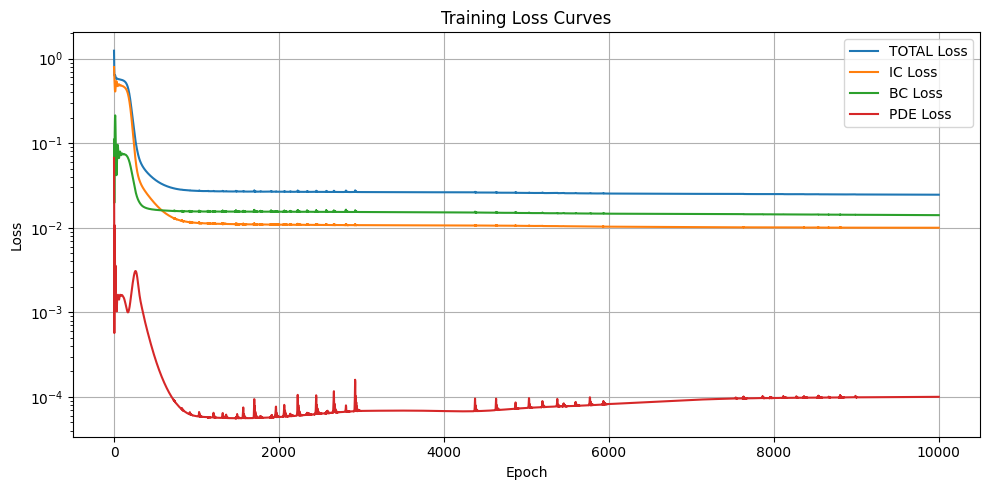

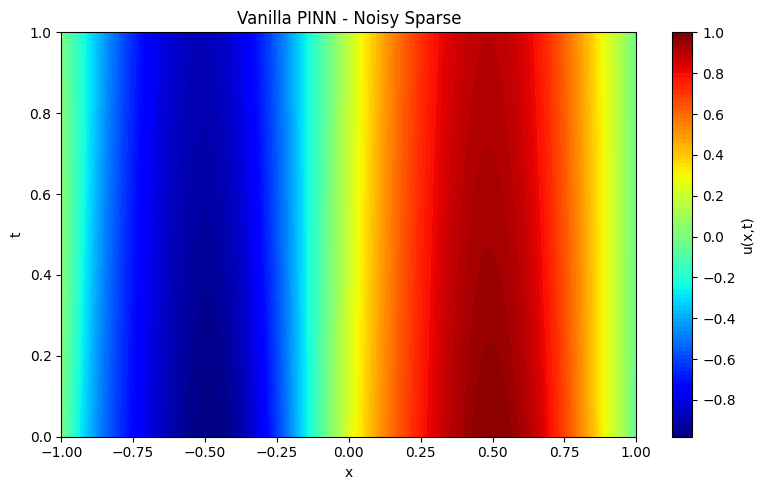

Saved: ../results/heat/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Heat | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Noisy Sparse')
save_history(h_vn, RESULTS+'vanilla_noisy_history.npy')

## Section 5 - AC-PINN, Clean Dense

Epoch     0 | Stage 1/4 | Total: 0.693702 | IC: 0.598684 | BC: 0.047378 | PDE: 0.009528 | λ=(1.00,1.00,5.00)


Epoch  1000 | Stage 1/4 | Total: 0.000996 | IC: 0.000118 | BC: 0.000068 | PDE: 0.000025 | λ=(5.63,1.26,10.00)


Epoch  2000 | Stage 1/4 | Total: 0.000232 | IC: 0.000024 | BC: 0.000027 | PDE: 0.000007 | λ=(5.23,1.27,10.00)


Epoch  3000 | Stage 2/4 | Total: 0.000193 | IC: 0.000017 | BC: 0.000015 | PDE: 0.000006 | λ=(6.59,1.28,10.00)


Epoch  4000 | Stage 2/4 | Total: 0.000110 | IC: 0.000010 | BC: 0.000013 | PDE: 0.000003 | λ=(6.95,1.19,10.00)


...

Epoch  6000 | Stage 3/4 | Total: 0.000028 | IC: 0.000006 | BC: 0.000007 | PDE: 0.000012 | λ=(0.75,0.84,1.40)


Epoch  7000 | Stage 3/4 | Total: 0.000023 | IC: 0.000006 | BC: 0.000005 | PDE: 0.000010 | λ=(0.84,0.73,1.43)


Epoch  8000 | Stage 4/4 | Total: 0.000068 | IC: 0.000010 | BC: 0.000012 | PDE: 0.000031 | λ=(0.57,0.70,1.74)


Epoch  9000 | Stage 4/4 | Total: 0.000040 | IC: 0.000008 | BC: 0.000011 | PDE: 0.000017 | λ=(0.69,0.88,1.43)



AC-PINN training complete in 262.30s


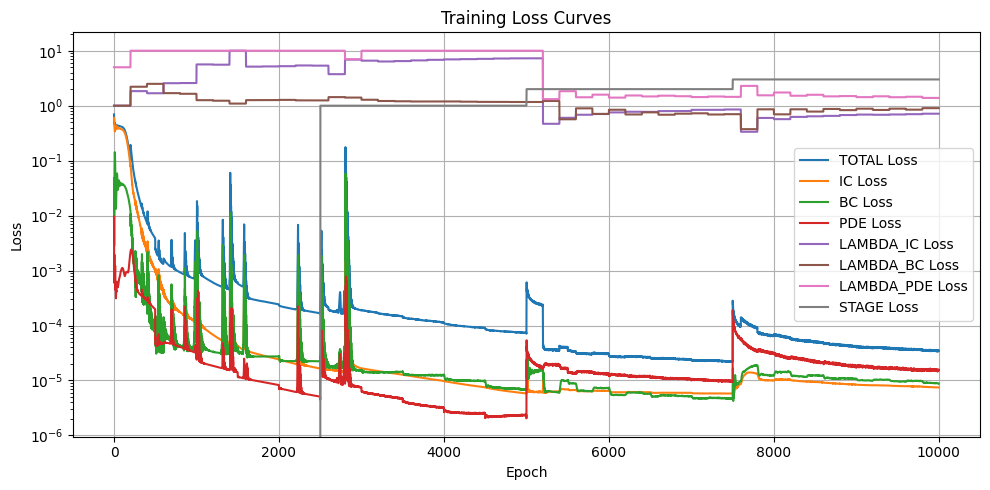

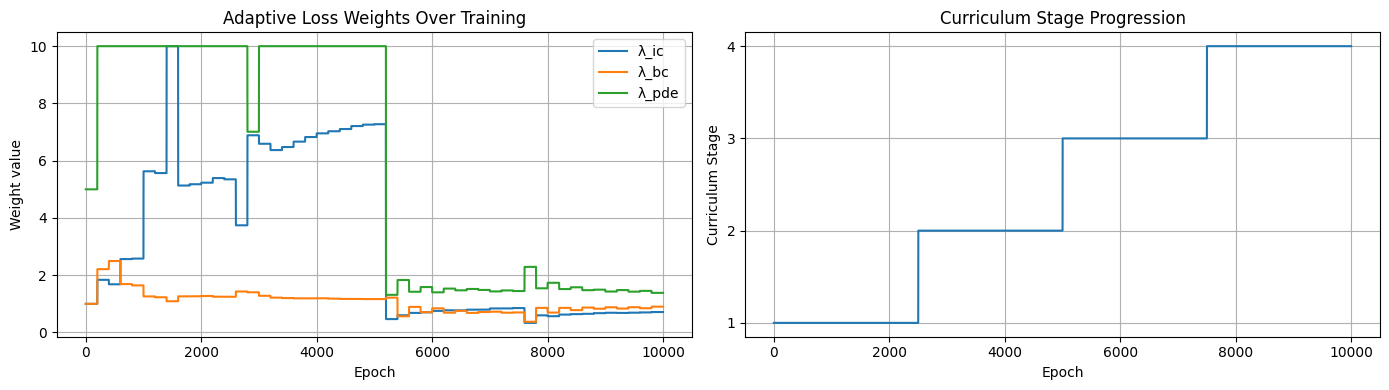

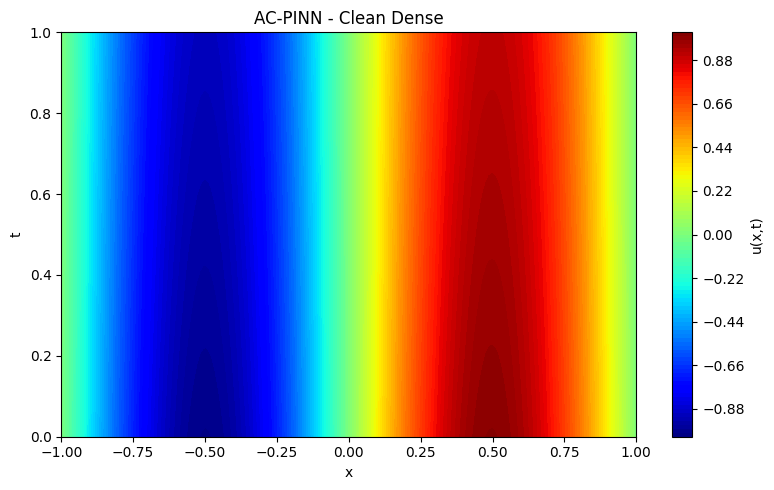

Saved: ../results/heat/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Heat | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Clean Dense')
save_history(h_ac, RESULTS+'ac_clean_history.npy')

## Section 6 - AC-PINN, Noisy Sparse

Epoch     0 | Stage 1/4 | Total: 1.642819 | IC: 0.255974 | BC: 0.987728 | PDE: 0.079823 | λ=(1.00,1.00,5.00)


Epoch  1000 | Stage 1/4 | Total: 0.073378 | IC: 0.011136 | BC: 0.015929 | PDE: 0.000029 | λ=(4.72,1.29,10.00)


Epoch  2000 | Stage 1/4 | Total: 0.059527 | IC: 0.010810 | BC: 0.015719 | PDE: 0.000011 | λ=(3.42,1.43,10.00)


Epoch  3000 | Stage 2/4 | Total: 0.096528 | IC: 0.010422 | BC: 0.015147 | PDE: 0.000110 | λ=(7.39,1.22,10.00)


Epoch  4000 | Stage 2/4 | Total: 0.074512 | IC: 0.010165 | BC: 0.014708 | PDE: 0.000111 | λ=(5.38,1.27,10.00)


...

Epoch  6000 | Stage 3/4 | Total: 0.031841 | IC: 0.009760 | BC: 0.012547 | PDE: 0.001809 | λ=(1.21,1.56,0.23)


Epoch  7000 | Stage 3/4 | Total: 0.029406 | IC: 0.009785 | BC: 0.011477 | PDE: 0.002674 | λ=(1.23,1.44,0.34)


Epoch  8000 | Stage 4/4 | Total: 0.030698 | IC: 0.009604 | BC: 0.012725 | PDE: 0.004412 | λ=(1.08,1.43,0.49)


Epoch  9000 | Stage 4/4 | Total: 0.030925 | IC: 0.009600 | BC: 0.012716 | PDE: 0.003493 | λ=(1.12,1.48,0.41)



AC-PINN training complete in 262.35s


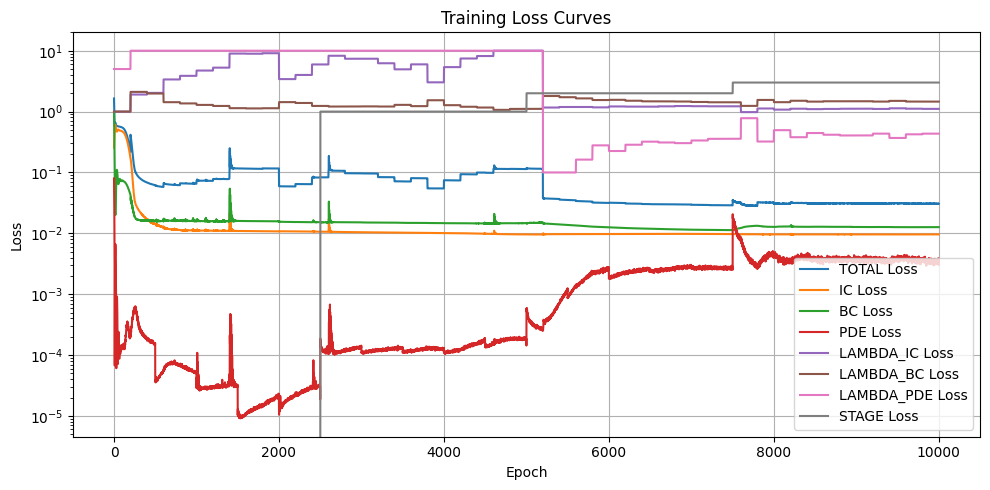

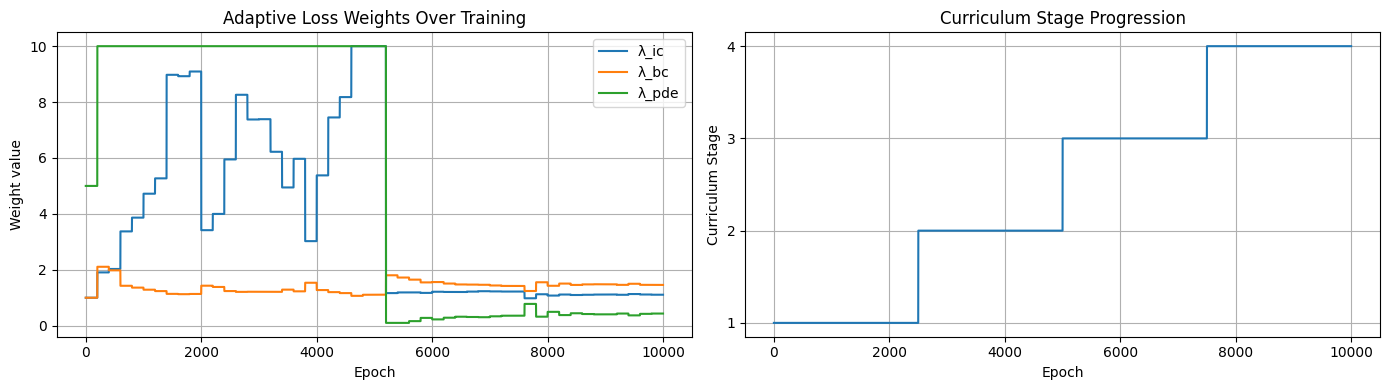

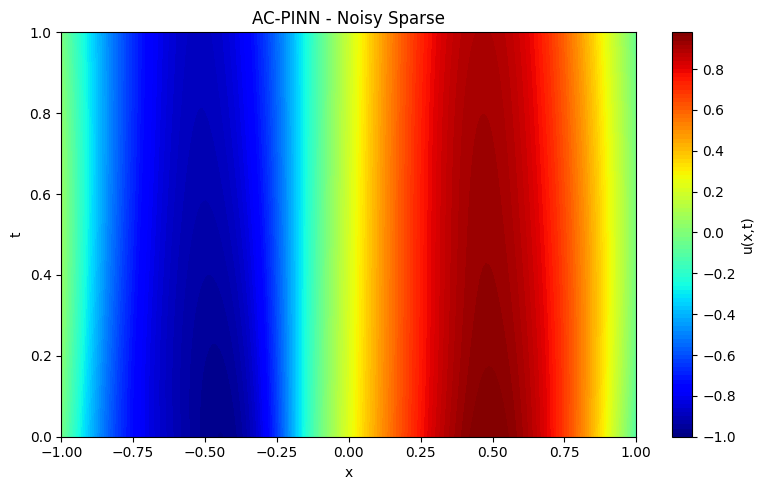

Saved: ../results/heat/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Heat | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Noisy Sparse')
save_history(h_an, RESULTS+'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.002129   0.004995   0.001146   0.001431
  Vanilla (noisy)             0.123240   0.224612   0.059022   0.082844
  AC-PINN (clean)             0.002494   0.006392   0.001321   0.001676
  AC-PINN (noisy)             0.126721   0.255319   0.058358   0.085185


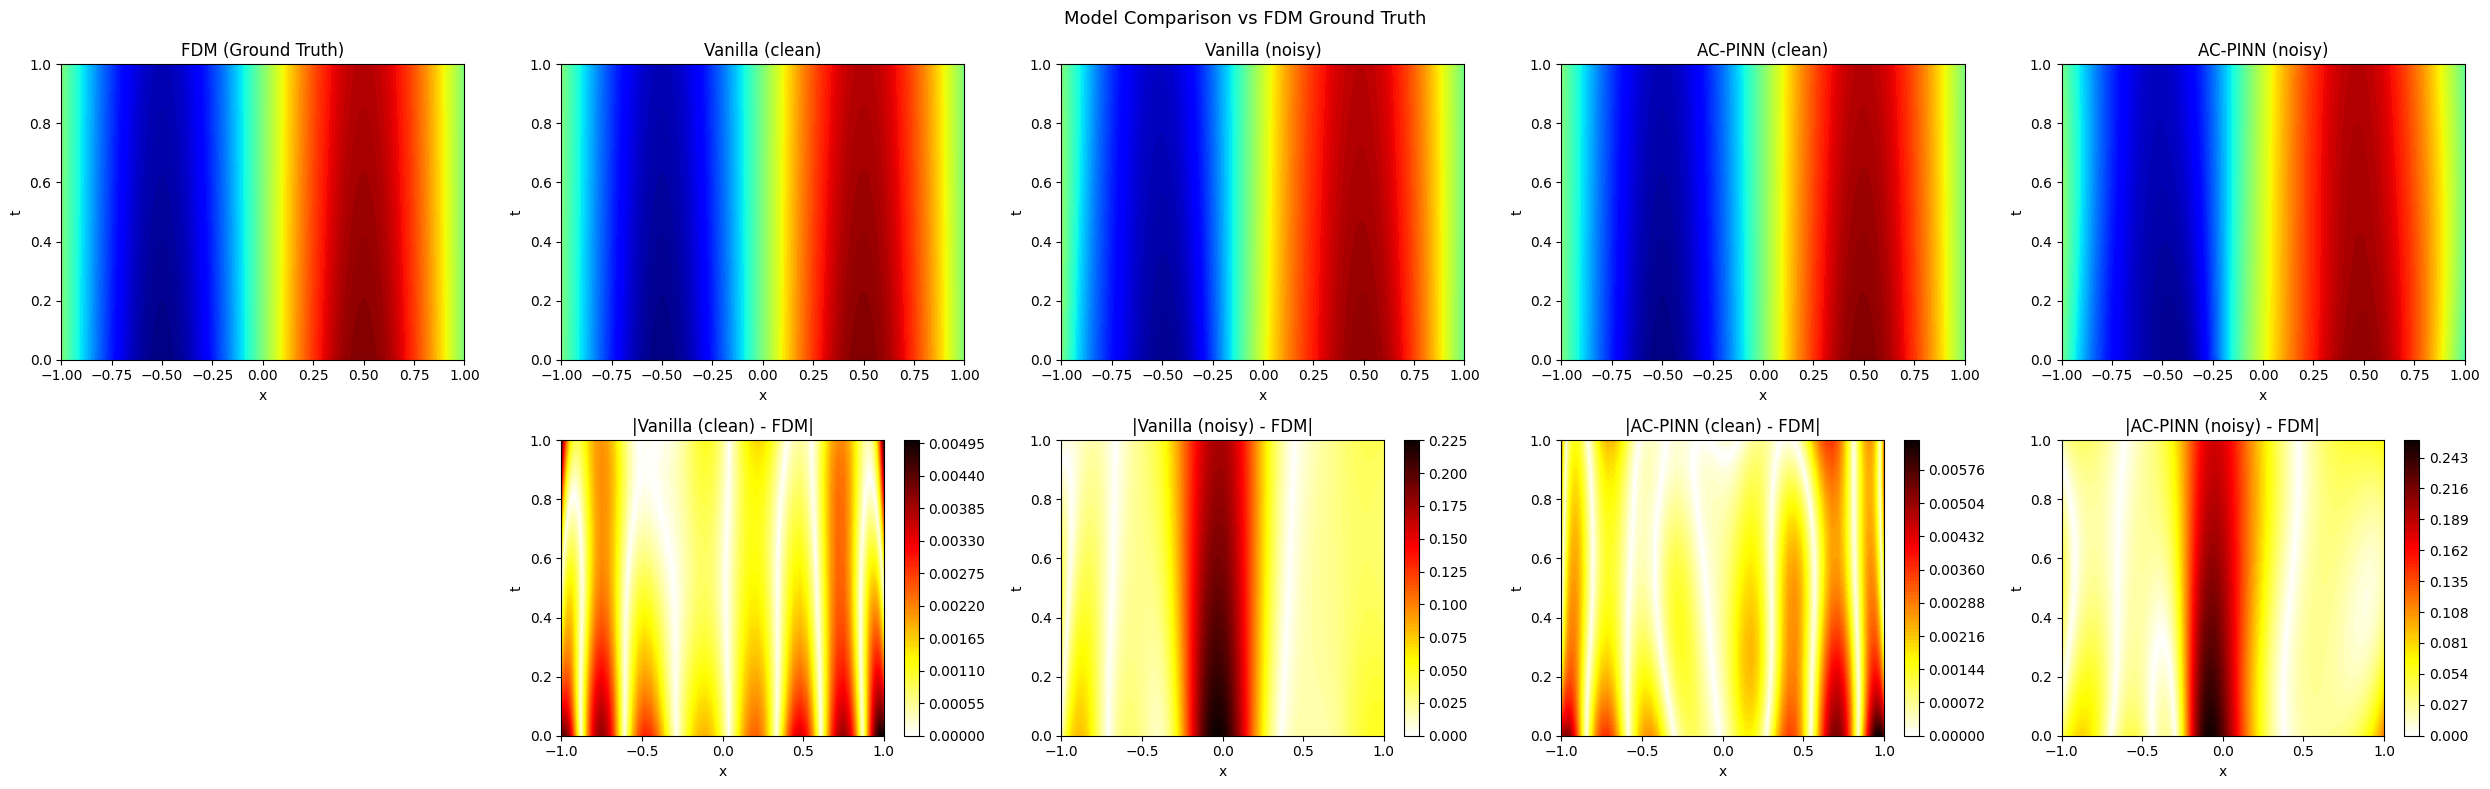

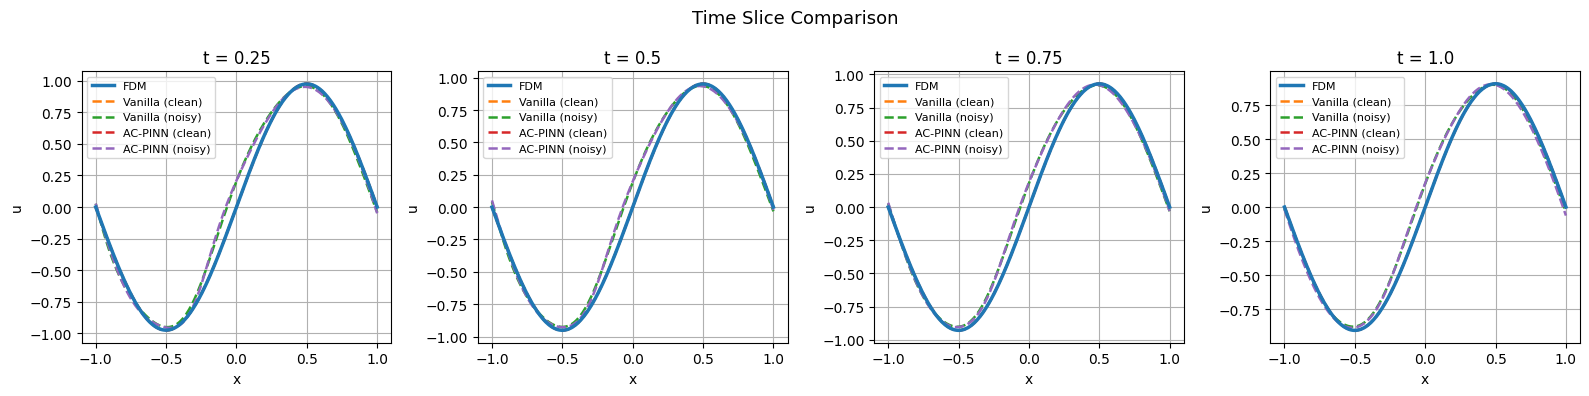

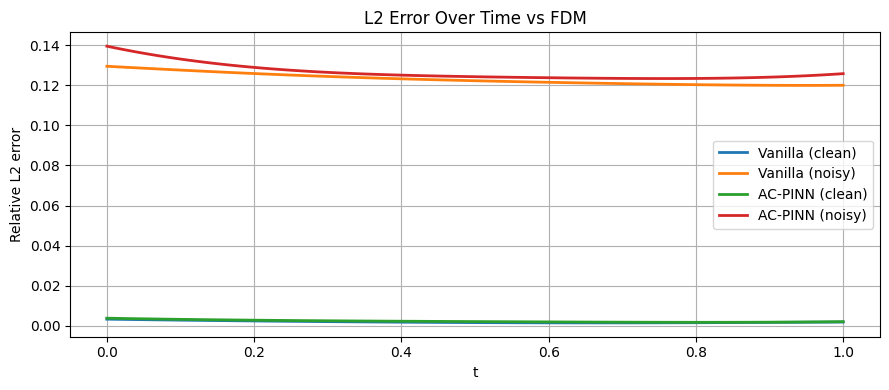

Saved: ../results/heat/benchmark_metrics.npy
Heat experiments complete.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)', vanilla_clean)
bench.add('Vanilla (noisy)', vanilla_noisy)
bench.add('AC-PINN (clean)', ac_clean)
bench.add('AC-PINN (noisy)', ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Heat experiments complete.')

## Section 8 - Noise Level Study

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=3000, noise_eps=eps)
    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
    v.fit(d, epochs=5000, print_every=2500)
    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)
    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()
save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')


--- ε=0.05 ---
Epoch     0 | Total: 0.479228 | IC: 0.419056 | BC: 0.054767 | PDE: 0.001081


Epoch  2500 | Total: 0.008661 | IC: 0.002246 | BC: 0.006303 | PDE: 0.000023



Training complete in 112.99s
Epoch     0 | Stage 1/4 | Total: 1.003670 | IC: 0.618280 | BC: 0.096951 | PDE: 0.057688 | λ=(1.00,1.00,5.00)


Epoch  2500 | Stage 2/4 | Total: 0.016711 | IC: 0.002091 | BC: 0.006199 | PDE: 0.000006 | λ=(3.27,1.58,10.00)



AC-PINN training complete in 121.46s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.023423   0.042692   0.012767   0.015745
  AC-PINN ε=0.05              0.026409   0.040386   0.014567   0.017753

--- ε=0.1 ---
Epoch     0 | Total: 0.485364 | IC: 0.366503 | BC: 0.077245 | PDE: 0.008323


...


AC-PINN training complete in 54.00s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.044931   0.070365   0.024215   0.030203
  AC-PINN ε=0.1               0.055064   0.101526   0.026504   0.037015

--- ε=0.2 ---
Epoch     0 | Total: 1.385793 | IC: 0.934089 | BC: 0.443391 | PDE: 0.001663


Epoch  2500 | Total: 0.075120 | IC: 0.027799 | BC: 0.046807 | PDE: 0.000103



Training complete in 46.34s
Epoch     0 | Stage 1/4 | Total: 1.709730 | IC: 0.424666 | BC: 0.278653 | PDE: 0.201282 | λ=(1.00,1.00,5.00)


Epoch  2500 | Stage 2/4 | Total: 0.199783 | IC: 0.031269 | BC: 0.042552 | PDE: 0.000082 | λ=(1.78,3.38,7.11)



AC-PINN training complete in 53.45s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.089057   0.162873   0.049296   0.059866
  AC-PINN ε=0.2               0.071337   0.128491   0.039116   0.047954
Saved: ../results/heat/noise_study_metrics.npy
